In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date','Ship Date','Lead Time']].head()

,Order Date,Ship Date,Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [4]:
df = df[df['Lead Time'] < 100]
df = df[df['Lead Time'] >= 0]

In [5]:
route_analysis = df.groupby(['State/Province', 'Region']).agg({
    'Lead Time': 'mean',
    'Order ID': 'count'
}).reset_index()

route_analysis.rename(columns={
    'Lead Time': 'Avg Lead Time',
    'Order ID': 'Total Orders'
}, inplace=True)

route_analysis.head()

,State/Province,Region,Avg Lead Time,Total Orders


In [6]:
top_routes = route_analysis.nsmallest(10, 'Avg Lead Time')
bottom_routes = route_analysis.nlargest(10, 'Avg Lead Time')

top_routes

,State/Province,Region,Avg Lead Time,Total Orders


In [7]:
bottom_routes

,State/Province,Region,Avg Lead Time,Total Orders


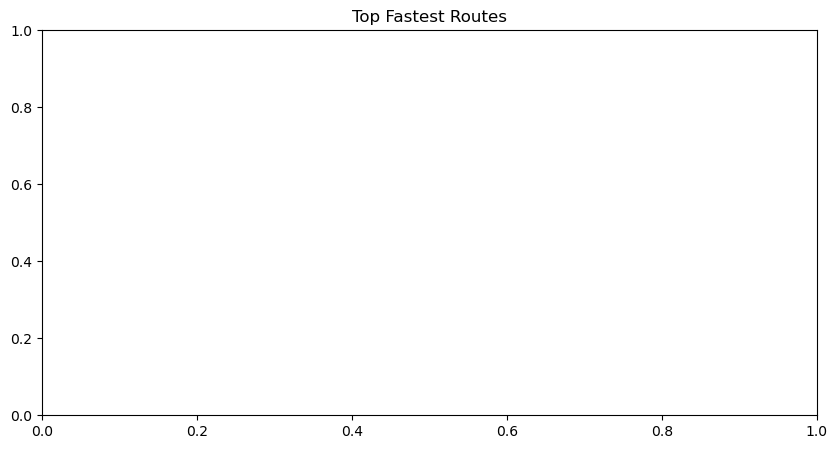

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(data=top_routes, x='Avg Lead Time', y='State/Province')
plt.title('Top Fastest Routes')
plt.show()

In [9]:
print(len(df))
print(df['Lead Time'].describe())

0
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Lead Time, dtype: float64


In [10]:
df = pd.read_csv('data.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [12]:
print(len(df))
df['Lead Time'].describe()

10194


count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64

In [13]:
route_analysis = df.groupby(['State/Province', 'Region']).agg({
    'Lead Time': 'mean',
    'Order ID': 'count'
}).reset_index()

route_analysis.head()

,State/Province,Region,Lead Time,Order ID
0,Alabama,Gulf,1291.278689,61
1,Alberta,Pacific,1274.076923,26
2,Arizona,Pacific,1309.214286,224
3,Arkansas,Gulf,1285.733333,60
4,British Columbia,Pacific,1290.318182,22


In [14]:
route_analysis = df.groupby(['State/Province', 'Region']).agg({
    'Lead Time': 'mean',
    'Order ID': 'count'
}).reset_index()

route_analysis.head()

,State/Province,Region,Lead Time,Order ID
0,Alabama,Gulf,1291.278689,61
1,Alberta,Pacific,1274.076923,26
2,Arizona,Pacific,1309.214286,224
3,Arkansas,Gulf,1285.733333,60
4,British Columbia,Pacific,1290.318182,22


In [15]:
bottom_routes

,State/Province,Region,Avg Lead Time,Total Orders


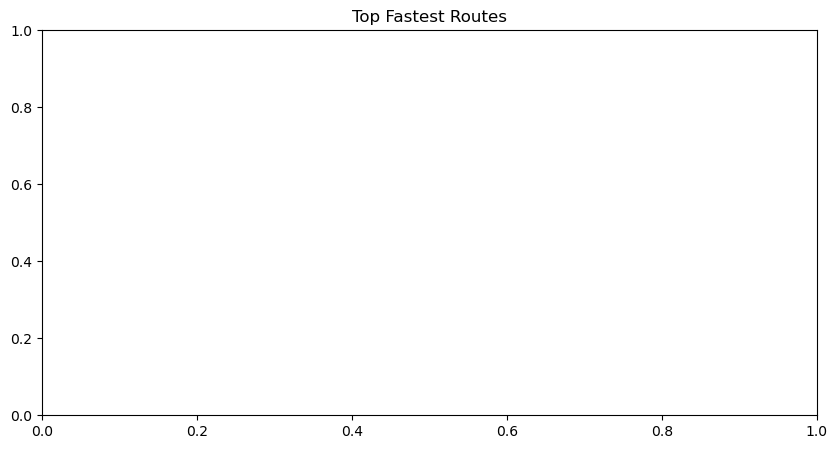

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(data=top_routes, x='Avg Lead Time', y='State/Province')
plt.title('Top Fastest Routes')
plt.show()

In [19]:

route_analysis.rename(columns={
    'Lead Time': 'Avg Lead Time',
    'Order ID': 'Total Orders'
}, inplace=True)

In [20]:
top_routes = route_analysis.nsmallest(10, 'Avg Lead Time')

In [21]:
top_routes

,State/Province,Region,Avg Lead Time,Total Orders
19,Maine,Atlantic,1137.125000,8
35,Newfoundland and Labrador,Atlantic,1216.166667,6
29,Nevada,Pacific,1226.794872,39
54,Virginia,Gulf,1229.125000,224
41,Ontario,Atlantic,1247.465517,58
52,Utah,Pacific,1253.000000,53
48,South Carolina,Gulf,1255.428571,42
18,Louisiana,Gulf,1263.785714,42
25,Mississippi,Gulf,1266.566038,53
42,Oregon,Pacific,1267.709677,124


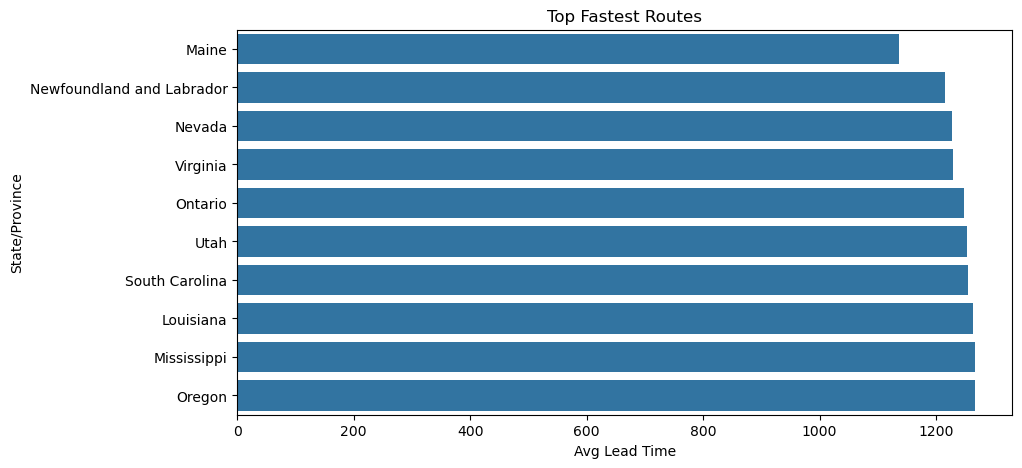

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(data=top_routes, x='Avg Lead Time', y='State/Province')
plt.title('Top Fastest Routes')
plt.show()

In [23]:
ship_mode = df.groupby('Ship Mode')['Lead Time'].mean().reset_index()
ship_mode

,Ship Mode,Lead Time
0,First Class,1338.275840
1,Same Day,1333.442413
2,Second Class,1323.845376
3,Standard Class,1314.334641


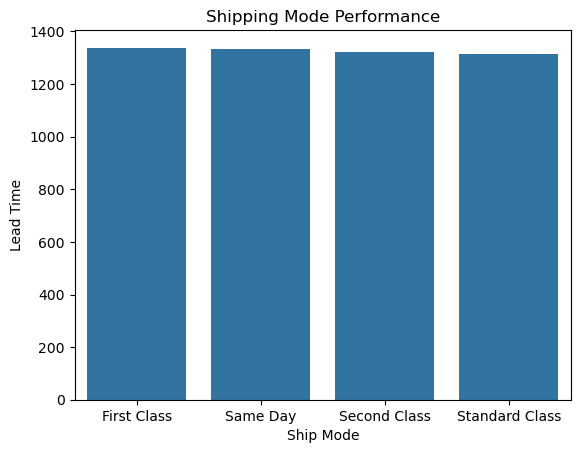

In [24]:
sns.barplot(data=ship_mode, x='Ship Mode', y='Lead Time')
plt.title('Shipping Mode Performance')
plt.show()

In [25]:
df.isnull().sum()
df.drop_duplicates(inplace=True)

In [26]:
avg_lead = df['Lead Time'].mean()
max_lead = df['Lead Time'].max()
min_lead = df['Lead Time'].min()

print("Average Lead Time:", avg_lead)
print("Max Lead Time:", max_lead)
print("Min Lead Time:", min_lead)

Average Lead Time: 1320.8418677653522
Max Lead Time: 1642
Min Lead Time: 904


In [27]:
threshold = df['Lead Time'].mean()
df['Delayed'] = df['Lead Time'] > threshold

df['Delayed'].value_counts()

Delayed
False    6815
True     3379
Name: count, dtype: int64

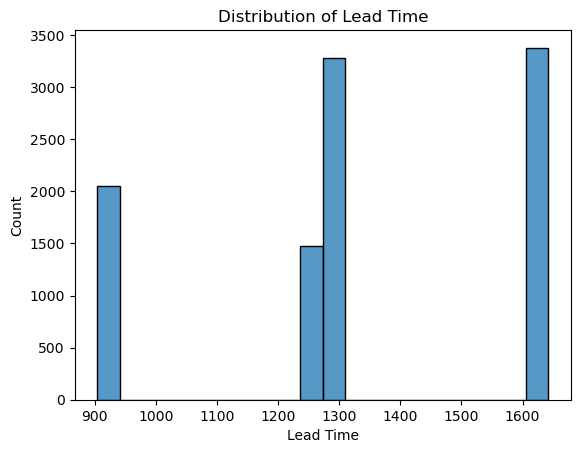

In [28]:
sns.histplot(df['Lead Time'], bins=20)
plt.title("Distribution of Lead Time")
plt.show()

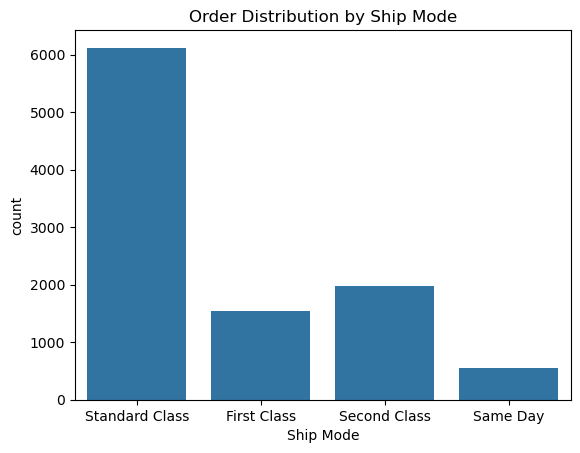

In [29]:
sns.countplot(x='Ship Mode', data=df)
plt.title("Order Distribution by Ship Mode")
plt.show()